In [ ]:
import os
import cv2
import numpy as np
import shutil
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from math import cos, sin, radians
import matplotlib.pyplot as plt
import random
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load dataset using OpenCV

def load_dataset(dataset_path):
    images = []
    labels = []
    for label in sorted(os.listdir(dataset_path)):
        subfolder = os.path.join(dataset_path, label)
        
        for filename in os.listdir(subfolder):
            file_path = os.path.join(subfolder, filename)
            img = cv2.imread(file_path)       
            images.append(img)
            labels.append(label)  #use the subfolder name as label
    
    return images, labels
train_path = "asl_alphabet_minimal"
X_train, y_train = load_dataset(train_path)

print("Train images:", len(X_train))
print("train labels:", len(y_train))

Immagini train: 2515
Etichette train: 2515
Esempio dimensioni: (400, 400, 3)


In [ ]:
#Transform RGB images into binary masks and crop them

dataset_path = "asl_alphabet_minimal"
output_path = "asl_alphabet_mask_cropped"

#clean output directory
if os.path.exists(output_path):
    shutil.rmtree(output_path)
os.makedirs(output_path, exist_ok=True)

#Function to create mask from non-black pixels
def create_mask(img_bgr, threshold=10):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = np.where(gray > threshold, 255, 0).astype(np.uint8)
    return mask

#for each letter create a folder in the output path and process images
letters = sorted(os.listdir(dataset_path))
for letter in letters:
    folder = os.path.join(dataset_path, letter)
    if not os.path.isdir(folder):
        continue

    out_folder = os.path.join(output_path, letter)
    os.makedirs(out_folder, exist_ok=True)

    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue

        mask = create_mask(img) #create the mask
        ys, xs = np.where(mask > 0) #find non-black pixels

        if len(xs) == 0 or len(ys) == 0:
            continue

        x0, x1 = xs.min(), xs.max() #minimum and maximum x of white pixels
        y0, y1 = ys.min(), ys.max() #minimum and maximum y of white pixels

        crop_mask = mask[y0:y1+1, x0:x1+1] #Mask crop to only significant pixels

        out_mask_path = os.path.join(out_folder, filename) #save the cropped mask in the output directory
        cv2.imwrite(out_mask_path, crop_mask)


In [ ]:
#Function to extract hand contour. Contour points are: 
# white pixels with at least one black neighbor 
# or 
# white pixels on the image border

def extract_contour(mask):

    h, w = mask.shape #height and width of the mask
    contour = []

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 0: # black pixel
                continue

            if x == 0 or x == w-1 or y == 0 or y == h-1: #white pixels on border
                contour.append((y, x))
                continue

            neighborhood = mask[y-1:y+2, x-1:x+2] #define 3x3 neighborhood
            if np.any(neighborhood == 0): #white pixels with at least one black neighbor
                contour.append((y, x))

    return contour

# Function to compute 360 radial distances (from center to contour in 360 directions)

def compute_radial_distances(mask, contour, num_angles=360):

    h, w = mask.shape

    cy = h // 2 #y for the image center
    cx = w // 2 #x for the image center

    center_is_black = (mask[cy, cx] == 0)

    contour_set = set(contour)
    signature = []

    for angle in range(num_angles):
        theta = radians(angle)
        dx = cos(theta)
        dy = sin(theta)

        dist = 0
        max_steps = max(h, w)

        found = False
        for step in range(1, max_steps):
            x = int(cx + dx * step)
            y = int(cy + dy * step)

            if x < 0 or x >= w or y < 0 or y >= h: #out of bounds
                signature.append(step)
                found = True
                break

            if (y, x) in contour_set: #contour pixel found
                signature.append(step)
                found = True
                break

        if not found: 
            signature.append(max_steps)

    return np.array(signature, dtype=np.float32), center_is_black

In [ ]:
#load the masks cropped and generate the features for k-NN 
dataset_path = "asl_alphabet_mask_cropped"

X = []
y = []

saved_examples = [] #for visualization
MAX_SHOW = 4

for label in sorted(os.listdir(dataset_path)):
    folder = os.path.join(dataset_path, label)
    if not os.path.isdir(folder):
        continue

    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        mask = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        contour = extract_contour(mask)
        if len(contour) == 0: #no contour found
            continue

        signature, center_is_black = compute_radial_distances(
            mask, contour, num_angles=360
        )

        if center_is_black: #center pixel is black so our features are not reliable
            continue

        if not center_is_black and len(saved_examples) < MAX_SHOW and random.random() < 0.05:
            saved_examples.append((mask, contour))

        X.append(signature)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Sample size:", len(X))


Sample size: 1785


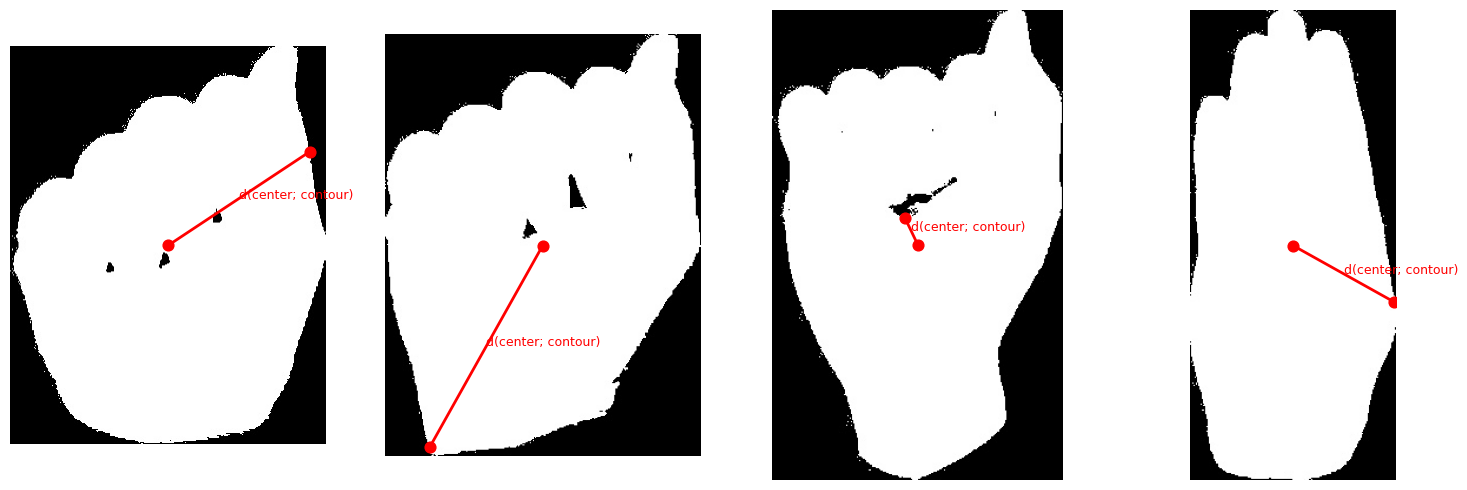

In [ ]:
#visualization radial distance feature

fig, axes = plt.subplots(1, len(saved_examples), figsize=(15, 5))

for ax, (mask, contour) in zip(axes, saved_examples):
    h, w = mask.shape
    cy, cx = h // 2, w // 2

    y_c, x_c = random.choice(contour)

    ax.imshow(mask, cmap="gray")

    ax.scatter(cx, cy, c="red", s=60)

    ax.scatter(x_c, y_c, c="red", s=60)

    ax.plot([cx, x_c], [cy, y_c], color="red", linewidth=2)

    mx = (cx + x_c) / 2
    my = (cy + y_c) / 2
    ax.text(mx, my, "d(center; contour)", color="red", fontsize=9)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Train-validation-test splitting

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_valid))
print("Test:", len(X_test))

#find the best k based on validation set and avarage accuracy metric

best_k = None
best_acc = -1

for k in range(1, 21): 
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train, y_train)
    pred = knn.predict(X_valid)
    acc = accuracy_score(y_valid, pred)

    print(f"k={k} -> Validation accuracy = {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("\nBest k:", best_k)
print("Accuracy validation with best k:", best_acc)

#Final train on train + validation set

X_final_train = np.vstack((X_train, X_valid))
y_final_train = np.concatenate((y_train, y_valid))

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_final.fit(X_final_train, y_final_train)

Train: 1249
Validation: 268
Test: 268
k=1 -> Validation accuracy = 0.8694
k=2 -> Validation accuracy = 0.8396
k=3 -> Validation accuracy = 0.8358
k=4 -> Validation accuracy = 0.8134
k=5 -> Validation accuracy = 0.7985
k=6 -> Validation accuracy = 0.7649
k=7 -> Validation accuracy = 0.7537
k=8 -> Validation accuracy = 0.7500
k=9 -> Validation accuracy = 0.7500
k=10 -> Validation accuracy = 0.7463
k=11 -> Validation accuracy = 0.7276
k=12 -> Validation accuracy = 0.7201
k=13 -> Validation accuracy = 0.7201
k=14 -> Validation accuracy = 0.7164
k=15 -> Validation accuracy = 0.7127
k=16 -> Validation accuracy = 0.7015
k=17 -> Validation accuracy = 0.6940
k=18 -> Validation accuracy = 0.6903
k=19 -> Validation accuracy = 0.6866
k=20 -> Validation accuracy = 0.6866

Best k: 1
Accuracy validation with best k: 0.8694029850746269


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# test
y_pred = knn_final.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", final_accuracy)
print("\nClassification report for each letter\n")

print(classification_report(y_test,y_pred,digits=4))

Test accuracy: 0.8917910447761194

Classification report for each letter

              precision    recall  f1-score   support

           a     0.8889    0.8000    0.8421        10
           b     1.0000    0.8000    0.8889        10
           c     1.0000    0.9000    0.9474        10
           d     0.8333    0.9091    0.8696        11
           e     0.6923    0.9000    0.7826        10
           f     0.8462    1.0000    0.9167        11
           g     0.8333    1.0000    0.9091        10
           h     1.0000    0.8000    0.8889        10
           i     0.8889    0.7273    0.8000        11
           j     0.9167    1.0000    0.9565        11
           k     1.0000    1.0000    1.0000        10
           l     0.9167    1.0000    0.9565        11
           m     1.0000    0.6000    0.7500        10
           n     0.7500    0.6000    0.6667        10
           o     0.9167    1.0000    0.9565        11
           p     0.9091    1.0000    0.9524        10
       